<a href="https://colab.research.google.com/github/zahramufida/Deep-Learning-/blob/main/UAS_MLPrak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalasi Library & Import

In [3]:
# Install library yang dibutuhkan
!pip install pytorch-tabnet imbalanced-learn scikit-learn tensorflow pandas numpy matplotlib seaborn -q

# Import semua library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


Upload & Load Dataset

In [4]:
from google.colab import files

print("📂 SILAKAN UPLOAD FILE 'healthcare-dataset-stroke-data.csv' SAAT TOMBOL DI BAWAH MUNCUL.")
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

print(f"\n✅ Dataset berhasil dimuat!")
print(f"Shape Dataset: {df.shape}")
print(f"\nDistribusi Target (Stroke):")
print(df['stroke'].value_counts())

# Hapus kolom 'id' karena tidak relevan untuk prediksi
if 'id' in df.columns:
    df = df.drop('id', axis=1)

📂 SILAKAN UPLOAD FILE 'healthcare-dataset-stroke-data.csv' SAAT TOMBOL DI BAWAH MUNCUL.


Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv

✅ Dataset berhasil dimuat!
Shape Dataset: (5110, 12)

Distribusi Target (Stroke):
stroke
0    4861
1     249
Name: count, dtype: int64


Preprocessing Pipeline

In [5]:
# Memisahkan fitur numerik dan kategorikal
numeric_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Pipeline untuk Numerik: Isi missing value dengan Median, lalu Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk Kategorikal: Isi missing value dengan 'missing', lalu One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan menjadi satu Preprocessor utuh
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Preprocessor Pipeline berhasil dibuat!")

✅ Preprocessor Pipeline berhasil dibuat!


Data Splitting, Transformasi & SMOTE

In [7]:
X = df.drop('stroke', axis=1)
y = df['stroke']

# 1. Split data DULU (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Data Training sebelum SMOTE: {y_train.value_counts().to_dict()}")

# 2. FIT Preprocessor HANYA pada data Training (Mencegah Data Leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 3. Konversi ke numpy array dense dan float32 (AMAN untuk Sparse & Dense)
# Penambahan kondisi if/else untuk mencegah error AttributeError
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray().astype(np.float32)
    X_test_processed = X_test_processed.toarray().astype(np.float32)
else:
    X_train_processed = X_train_processed.astype(np.float32)
    X_test_processed = X_test_processed.astype(np.float32)

# 4. Terapkan SMOTE HANYA pada data Training
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"Data Training setelah SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")
print("✅ Data Splitting dan SMOTE selesai!")

Data Training sebelum SMOTE: {0: 3403, 1: 174}
Data Training setelah SMOTE: {0: 3403, 1: 3403}
✅ Data Splitting dan SMOTE selesai!


In [ ]:
Metode 1 - DNN

In [8]:
def build_mlp_model(input_dim):
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Output biner
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

print("\n🚀 Training MLP/DNN...")
mlp_model = build_mlp_model(X_train_balanced.shape[1])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

mlp_history = mlp_model.fit(
    X_train_balanced, y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi MLP
mlp_y_pred_proba = mlp_model.predict(X_test_processed).flatten()
mlp_y_pred = (mlp_y_pred_proba > 0.5).astype(int)
print("✅ MLP/DNN Training Selesai!")


🚀 Training MLP/DNN...
Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7373 - auc: 0.8200 - loss: 0.4928 - val_accuracy: 0.8333 - val_auc: 0.0000e+00 - val_loss: 0.5656
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7968 - auc: 0.8712 - loss: 0.4192 - val_accuracy: 0.9200 - val_auc: 0.0000e+00 - val_loss: 0.4446
Epoch 3/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8090 - auc: 0.8837 - loss: 0.3942 - val_accuracy: 0.8965 - val_auc: 0.0000e+00 - val_loss: 0.4209
Epoch 4/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8246 - auc: 0.8975 - loss: 0.3753 - val_accuracy: 0.8943 - val_auc: 0.0000e+00 - val_loss: 0.4515
Epoch 5/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8356 - auc: 0.9058 - loss: 0.3575 - val_accuracy: 0.8260 - val_auc: 0.0000e+00 - val_loss: 0.4843
Epoch 6/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8407 - auc: 0.9137 - loss: 0.3450 - val_accuracy: 0.8994 - val_auc: 0.0000e+00 - val

Metode 2 - TabNet

In [9]:
print("\n🚀 Training TabNet...")
tabnet_model = TabNetClassifier(
    n_d=8, n_a=8, n_steps=3, gamma=1.3,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam, # Menggunakan PyTorch optimizer
    optimizer_params=dict(lr=0.02),
    mask_type='entmax',
    verbose=1
)

# TabNet menggunakan fit dari library aslinya
tabnet_model.fit(
    X_train=X_train_balanced, y_train=y_train_balanced,
    eval_set=[(X_test_processed, y_test)],
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=128,
)

# Prediksi TabNet
tabnet_y_pred_proba = tabnet_model.predict_proba(X_test_processed)[:, 1]
tabnet_y_pred = tabnet_model.predict(X_test_processed)
print("✅ TabNet Training Selesai!")


🚀 Training TabNet...
epoch 0  | loss: 0.56596 | val_0_auc: 0.80097 |  0:00:00s
epoch 1  | loss: 0.41178 | val_0_auc: 0.79037 |  0:00:01s
epoch 2  | loss: 0.36677 | val_0_auc: 0.79425 |  0:00:02s
epoch 3  | loss: 0.3596  | val_0_auc: 0.75937 |  0:00:02s
epoch 4  | loss: 0.3337  | val_0_auc: 0.78303 |  0:00:03s
epoch 5  | loss: 0.32591 | val_0_auc: 0.73496 |  0:00:03s
epoch 6  | loss: 0.32639 | val_0_auc: 0.74733 |  0:00:04s
epoch 7  | loss: 0.30283 | val_0_auc: 0.73383 |  0:00:05s
epoch 8  | loss: 0.28174 | val_0_auc: 0.69428 |  0:00:06s
epoch 9  | loss: 0.26336 | val_0_auc: 0.69494 |  0:00:07s
epoch 10 | loss: 0.2513  | val_0_auc: 0.69654 |  0:00:07s
epoch 11 | loss: 0.24666 | val_0_auc: 0.71074 |  0:00:08s
epoch 12 | loss: 0.24739 | val_0_auc: 0.72354 |  0:00:08s
epoch 13 | loss: 0.23419 | val_0_auc: 0.69513 |  0:00:09s
epoch 14 | loss: 0.23227 | val_0_auc: 0.69416 |  0:00:10s
epoch 15 | loss: 0.22132 | val_0_auc: 0.68018 |  0:00:10s
epoch 16 | loss: 0.24439 | val_0_auc: 0.71289 |  0

Evaluasi & Komparasi


📊 HASIL EVALUASI:
  Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
MLP/DNN  0.883888   0.106870 0.186667  0.135922 0.750434
 TabNet  0.529028   0.085787 0.893333  0.156542 0.800969


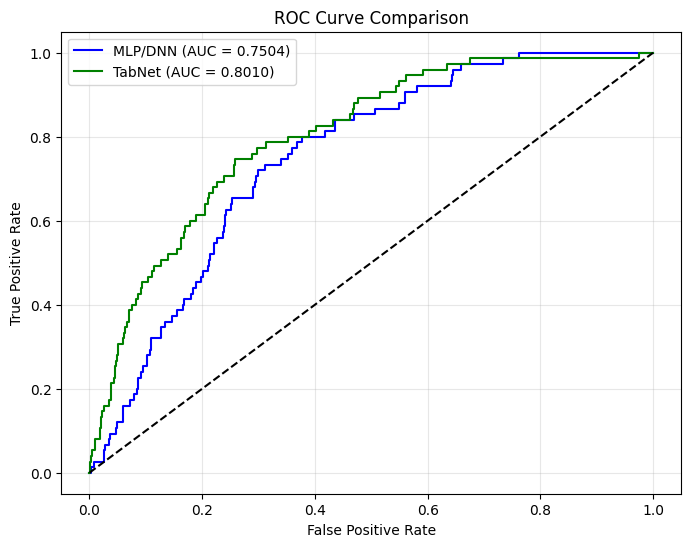

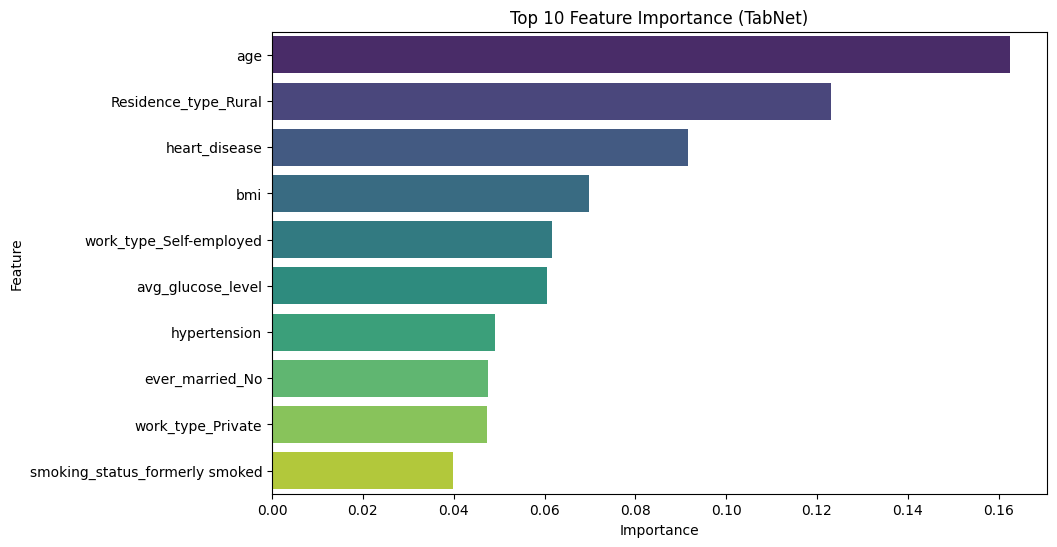

In [10]:
def get_metrics(y_true, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

metrics_mlp = get_metrics(y_test, mlp_y_pred, mlp_y_pred_proba, "MLP/DNN")
metrics_tabnet = get_metrics(y_test, tabnet_y_pred, tabnet_y_pred_proba, "TabNet")

df_metrics = pd.DataFrame([metrics_mlp, metrics_tabnet])
print("\n📊 HASIL EVALUASI:")
print(df_metrics.to_string(index=False))

# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr1, tpr1, _ = roc_curve(y_test, mlp_y_pred_proba)
fpr2, tpr2, _ = roc_curve(y_test, tabnet_y_pred_proba)
plt.plot(fpr1, tpr1, label=f"MLP/DNN (AUC = {metrics_mlp['ROC-AUC']:.4f})", color='blue')
plt.plot(fpr2, tpr2, label=f"TabNet (AUC = {metrics_tabnet['ROC-AUC']:.4f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature Importance TabNet
importances = tabnet_model.feature_importances_
# Ambil nama fitur hasil one-hot encoding dari preprocessor
ohe_columns = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_columns)

feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance (TabNet)')
plt.show()

Simpan Model untuk GUI (Output)

In [11]:
import joblib

# Tentukan model terbaik berdasarkan F1-Score
best_model_name = "TabNet" if metrics_tabnet['F1-Score'] > metrics_mlp['F1-Score'] else "MLP/DNN"
print(f"\n🏆 Model Terbaik: {best_model_name}")

# 1. Simpan Preprocessor (Wajib untuk GUI)
joblib.dump(preprocessor, 'preprocessor.pkl')
print("✅ preprocessor.pkl saved.")

# 2. Simpan Model
if best_model_name == "TabNet":
    tabnet_model.save_model('best_model_tabnet')
    print("✅ best_model_tabnet saved.")
else:
    mlp_model.save('best_model_mlp.h5')
    print("✅ best_model_mlp.h5 saved.")

# 3. Simpan nama fitur (untuk referensi)
joblib.dump(all_feature_names, 'feature_names.pkl')
print("✅ feature_names.pkl saved.")

print("\n🎉 PROSES SELESAI! File siap digunakan untuk Flask/FastAPI GUI.")


🏆 Model Terbaik: TabNet
✅ preprocessor.pkl saved.
Successfully saved model at best_model_tabnet.zip
✅ best_model_tabnet saved.
✅ feature_names.pkl saved.

🎉 PROSES SELESAI! File siap digunakan untuk Flask/FastAPI GUI.
